# Notebook 9 — Temporal Anomalies

The year-regression model from notebook 8 places 78% of songs within ±10 years of their actual release. The remaining 22% are interesting: they're songs whose **lyrics don't fit their era**.

We'll find these by:
1. Re-fitting the year-regression model
2. Computing residuals (predicted year − actual year) for every song
3. Sorting by absolute residual
4. Inspecting the extreme cases

Two phenomena to look for:
- **Throwback songs**: predicted older than they are (modern country re-using 1970s tropes, retro-soul, neo-doo-wop)
- **"Ahead of their time" songs**: predicted newer than they are (artists like Prince or Bowie writing lyrics that fit decades later)

These extremes are valuable because they reveal **what the model considers "of its era"** by showing what it considers out-of-era.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (13, 5)

PROCESSED_DIR = Path.cwd().parent / "data" / "processed"
df = pd.read_parquet(PROCESSED_DIR / "songs_with_topics.parquet")
df = df[df["decade"] >= 1950].copy().reset_index(drop=True)
print(f"Working with {len(df):,} songs")

Working with 6,456 songs


## Refit the year-regression model

Same approach as notebook 8's bonus cell. TF-IDF + Ridge regression on **all songs** this time — we want predictions for every song, not just a test set. (We'll use cross-validation predictions so we don't have leakage.)

In [2]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import Ridge
from sklearn.model_selection import KFold
from sklearn.pipeline import Pipeline

# 5-fold cross-validation: every song gets a prediction made by a model 
# that didn't see it during training
kf = KFold(n_splits=5, shuffle=True, random_state=42)
predictions = np.zeros(len(df))

X = df["lyrics_text"].values
y = df["year"].values

for fold, (train_idx, test_idx) in enumerate(kf.split(X), 1):
    pipe = Pipeline([
        ("tfidf", TfidfVectorizer(
            max_features=20000, ngram_range=(1, 2),
            min_df=5, max_df=0.7, sublinear_tf=True,
        )),
        ("ridge", Ridge(alpha=1.0)),
    ])
    pipe.fit(X[train_idx], y[train_idx])
    predictions[test_idx] = pipe.predict(X[test_idx])
    print(f"  Fold {fold} done")

df["predicted_year"] = predictions
df["residual"] = df["predicted_year"] - df["year"]
df["abs_residual"] = np.abs(df["residual"])

mae = df["abs_residual"].mean()
print(f"\nCross-validated MAE: {mae:.1f} years")

  Fold 1 done
  Fold 2 done
  Fold 3 done
  Fold 4 done
  Fold 5 done

Cross-validated MAE: 9.4 years


## Distribution of residuals

How are anomalies distributed? Plot the residual histogram and a per-year residual chart.

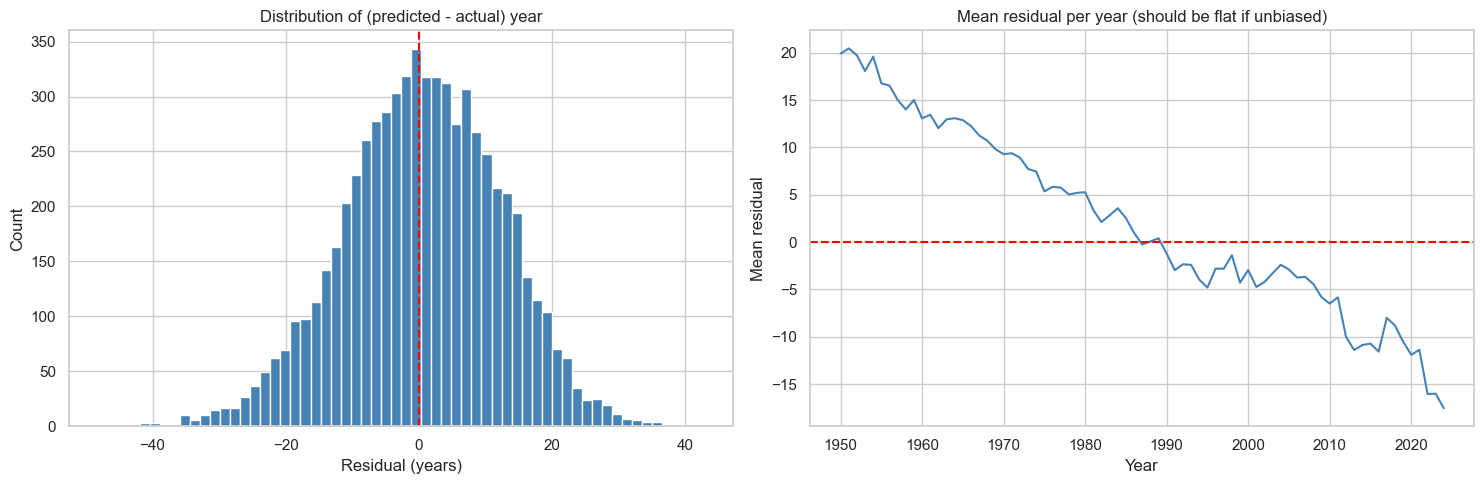

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histogram of residuals
axes[0].hist(df["residual"], bins=60, color="steelblue", edgecolor="white")
axes[0].axvline(0, color="red", linestyle="--")
axes[0].set_title("Distribution of (predicted - actual) year")
axes[0].set_xlabel("Residual (years)"); axes[0].set_ylabel("Count")

# Mean residual per year — does the model systematically over/under-predict any era?
yearly_resid = df.groupby("year")["residual"].mean()
axes[1].plot(yearly_resid.index, yearly_resid.values, color="steelblue")
axes[1].axhline(0, color="red", linestyle="--")
axes[1].set_title("Mean residual per year (should be flat if unbiased)")
axes[1].set_xlabel("Year"); axes[1].set_ylabel("Mean residual")
plt.tight_layout(); plt.show()

In [10]:
# Cell 6b — recalibrate residuals against per-year mean
yearly_bias = df.groupby("year")["residual"].mean()
df["residual_calibrated"] = df["residual"] - df["year"].map(yearly_bias)
df["abs_residual_calibrated"] = df["residual_calibrated"].abs()

# Now redo the top-25 lists using residual_calibrated instead of residual
ahead_calibrated = df.nlargest(20, "residual_calibrated")[
    ["year", "predicted_year", "residual_calibrated", "title", "artist"]
].copy()
print("CALIBRATED — songs anomalously ahead of their year (vs. peers from same year):")
print(ahead_calibrated.round(1).to_string(index=False))

throwback_calibrated = df.nsmallest(20, "residual_calibrated")[
    ["year", "predicted_year", "residual_calibrated", "title", "artist"]
].copy()
print("\nCALIBRATED — songs anomalously old-fashioned for their year:")
print(throwback_calibrated.round(1).to_string(index=False))

CALIBRATED — songs anomalously ahead of their year (vs. peers from same year):
 year  predicted_year  residual_calibrated                                title                                                                   artist
 2007          2034.6                 31.2                      Outta My System                               Bow Wow featuring T-Pain and Johntá Austin
 2024          2037.1                 30.7                             Euphoria                                                           Kendrick Lamar
 2015          2033.0                 28.7                I Don't Fuck with You                                                  Big Sean featuring E-40
 2014          2031.6                 28.4                            Lifestyle                       Rich Gang featuring Young Thug and Rich Homie Quan
 2015          2032.5                 28.2                            Blessings                                  Big Sean featuring Drake and Kanye West
 20

## The "ahead of their time" songs

Predicted *newer* than they are by the model. These songs use vocabulary or themes that became common later.

In [11]:
ahead = df.nlargest(25, "residual")[
    ["year", "predicted_year", "residual", "title", "artist"]
].copy()
ahead["predicted_year"] = ahead["predicted_year"].round().astype(int)
ahead["residual"] = ahead["residual"].round(1)
print("Songs predicted MUCH NEWER than they actually are (ahead of their time):")
print(ahead.to_string(index=False))

Songs predicted MUCH NEWER than they actually are (ahead of their time):
 year  predicted_year  residual                       title                           artist
 1951            1994      42.6                   Sound Off                    Vaughn Monroe
 1953            1994      40.6 St. George and the Dragonet                     Stan Freberg
 1951            1986      35.4                          If   Perry Como with Mitchell Ayres
 1960            1995      35.3       You Got What It Takes                     Marv Johnson
 1959            1994      35.2       Guitar Boogie Shuffle                      The Virtues
 1967            2002      35.1  (We Ain't Got) Nothin' Yet                     Blues Magoos
 1970            2005      34.7  Mama Told Me (Not to Come)                  Three Dog Night
 1950            1984      34.1            I Wanna Be Loved Andrews Sisters & Gordon Jenkins
 1959            1993      33.7         (Till) I Kissed You              The Everly Brothe

## The "throwback" songs

Predicted *older* than they are. These songs use the vocabulary and themes of a previous era.

In [12]:
throwback = df.nsmallest(25, "residual")[
    ["year", "predicted_year", "residual", "title", "artist"]
].copy()
throwback["predicted_year"] = throwback["predicted_year"].round().astype(int)
throwback["residual"] = throwback["residual"].round(1)
print("Songs predicted MUCH OLDER than they actually are (throwbacks):")
print(throwback.to_string(index=False))

Songs predicted MUCH OLDER than they actually are (throwbacks):
 year  predicted_year  residual                                title                                          artist
 2020            1972     -48.0                ILY (I Love You Baby)                      Surf Mesa featuring Emilee
 2023            1978     -45.0                          Bloody Mary                                       Lady Gaga
 2013            1970     -42.5     The Fox (What Does the Fox Say?)                                           Ylvis
 2013            1972     -41.2                         Harlem Shake                                          Baauer
 2023            1982     -41.1                                Cupid                                     Fifty Fifty
 2022            1981     -40.6                         Flower Shops                  Ernest featuring Morgan Wallen
 2023            1983     -39.9                    Until I Found You                                 Stephen Sanchez


## Which artists are the most temporally "off"?

Some artists might consistently write lyrics that don't fit their era. Aggregate residuals per artist (for artists with at least 3 charting songs) to find the most temporally distinctive.

In [7]:
# Artists with 3+ songs in our data
artist_residuals = (df.groupby("artist")
                       .agg(n_songs=("id", "count"),
                            mean_residual=("residual", "mean"),
                            mean_year=("year", "mean"))
                       .query("n_songs >= 3")
                       .sort_values("mean_residual"))

print("Artists who sound MOST OLDER than their era (consistent throwbacks):")
print(artist_residuals.head(15).round(1))

print("\nArtists who sound MOST NEWER than their era (ahead of their time):")
print(artist_residuals.tail(15).round(1)[::-1])

Artists who sound MOST OLDER than their era (consistent throwbacks):
                      n_songs  mean_residual  mean_year
artist                                                 
Sabrina Carpenter           4          -27.6     2024.0
Panic! at the Disco         3          -25.3     2014.7
Luke Combs                 16          -23.2     2021.2
Lewis Capaldi               3          -22.9     2019.7
Chris Stapleton             3          -22.7     2022.3
Lee Brice                   4          -22.4     2016.2
Lainey Wilson               3          -21.4     2022.3
Zac Brown Band              3          -20.4     2009.7
Harry Styles                6          -20.2     2020.7
Pitbull                     3          -18.9     2010.0
Bobby Helms                 3          -18.8     2023.0
XXXTentacion                4          -18.8     2017.8
Natalie Merchant            3          -18.5     1995.7
Charlie Puth                3          -18.5     2017.0
Florida Georgia Line        5      

## Save anomaly data

In [8]:
df.to_parquet(PROCESSED_DIR / "songs_with_anomalies.parquet")
print(f"Saved {len(df):,} songs with year predictions and residuals")

Saved 6,456 songs with year predictions and residuals
